In [1]:
%load_ext autoreload
%autoreload 2

from Shared.shared import *
from Shared.specific_CNB_sim import *

sim_name = f"SunNoG"
sim_folder = f"sim_output/{sim_name}"

fig_folder = f"figures_local/{sim_name}"
Cl_folder = f"Shared/Cls"
nu_m_range = jnp.load(f"{sim_folder}/neutrino_massrange_eV.npy")
nu_m_picks = jnp.array([0.01, 0.05, 0.1, 0.2, 0.3])*Params.eV
simdata = SimData(sim_folder)

## Computing $n_\nu$: total neutrino population

#### Boosted Fermi-Dirac Distribution

When observing the CNB from Earth's reference frame (moving relative to CNB), we need to properly transform the distribution:

1. **Starting Point**:
   - In CNB frame: f(p) = 1/(exp(p/T_CNB) + 1)
   - Distribution must remain invariant under frame change: f'(p') = f(p)
   
2. **(General) Lorentz Transformations**:
   - Energy transforms as: E' = γE(1 - β·p̂)
   - Momentum magnitude transforms similarly: p' = γp(1 - β·p̂)
   - Therefore p'/E' = p/E (direction transforms the same way for p and E)
   - This implies that p/T must transform as: (p/T)' = p'/T'
   
3. **Deriving Effective Temperature**:
   - From p'/T' = p/T and p' = γp(1 - β·p̂)
   - We get: T' = T_CNB / [γ(1 - β·p̂)]
   where γ is Lorentz factor, β = v/c is Earth's velocity relative to CNB, p̂ is momentum direction

Final distribution:
   f(p') = 1/(exp(p'/T') + 1)
where:
- p' is momentum transformed to Earth frame (via velocity addition)
- T' is direction-dependent effective temperature accounting for relativistic Doppler effect

In [ ]:
def compute_nu_dens_days(days_steps, args):

    # List to store quantities for each day
    days_nrs_l = []
    n_nu_days_l = []

    # Get Earth velocities w.r.t. the GC, since DM sims are in that frame
    # note: This includes ("inherited") solar system motion
    # Using specific astropy functionality for speed (more accurate)
    _, _, earth_vels = SimPlot.SunEarthGC_frame_coords_posvel(2024)
    earth_vels *= (args.km/args.s)/(args.kpc/args.s)

    for day in range(0, 365, days_steps):

        # Load velocities for current day
        file_path = f"{sim_folder}/vectors_day{day+1}.npy"

        if os.path.exists(file_path):

            print(f"Day {day+1}/365")
            days_nrs_l.append(day+1)

            # (insert halo dimension at beginning to synchronize)
            day_vels = jnp.load(file_path)[..., 3:][None, ...]
            
            ### Doppler shifted CNB velocities ###

            # Velocities from simulation frame to Earth frame
            # day_vels = SimUtil.CNB_to_Earth_frame_trafo(
            #     day_vels,
            #     earth_vels[day])

            # Sorted momenta arrays
            # _, p_z0_days, p_z4_days, _, _ = Utils.sim_vels_to_sorted_z0z4(
            #     day_vels, nu_m_picks, 
            #     merge_last_axes=False, args=Params())
            # PSDs_days = Physics.Fermi_Dirac(p_z4_days, Params())
            

            ### Boosted Fermi Dirac ###
            
            _, p_vec_z0_days, p_vec_z4_days, p_z0_days, p_z4_days, _, _ = Utils.sim_vels_to_sorted_z0z4_vec(
                day_vels, nu_m_picks, merge_last_axes=False, args=Params())
            
            # All in numerical (natural) units
            PSDs_days = Physics.Fermi_Dirac_boosted(
                p_vec_z4_days, earth_vels[day]*(args.kpc/args.s), Params())

            # note: integration over individual pixels
            n_raw = trap(p_z0_days**3*PSDs_days, jnp.log(p_z0_days), axis=-1)
            pix_sr = 4*args.Pi/simdata.Npix
            n_cm3 = pix_sr*args.g_nu/((2*args.Pi)**3)*n_raw/args.cm**-3
            n_cm3_pix = jnp.array(n_cm3)
            n_tot = jnp.sum(n_cm3_pix, axis=-1)
            n_nu_days_l.append(n_tot)

    return jnp.array(days_nrs_l), jnp.array(n_nu_days_l)


days_nrs, n_nu_days = compute_nu_dens_days(days_steps=12, args=Params())

# suffix = "_test"
# suffix = ""
# suffix = "_circular"
# suffix = "_circular_Earth_frame"
# suffix = "_circular_Earth_frame_dipoleFD"
# suffix = "_circular_FD_boosted"

# suffix = "_Sun_MW_p_Earth_FD_boost"
# suffix = "_Sun_MW_FD_boost"
# suffix = "_Sun_CNB_p_Earth_FD_boost"
suffix = "_Sun_CNB_FD_boost"


# nu_base_name = "n_nu_days_circular_Earth_frame_dipoleFD"
nu_base_name = f"n_nu_days{suffix}"
jnp.save(f"{sim_folder}/{nu_base_name}.npy", n_nu_days)

# nrs_base_name = "days_nrs_circular_Earth_frame_dipoleFD"
nrs_base_name = f"days_nrs{suffix}"
jnp.save(f"{sim_folder}/{nrs_base_name}.npy", days_nrs)

Day 1/365
Day 13/365
Day 25/365
Day 37/365
Day 49/365
Day 61/365
Day 73/365
Day 85/365
Day 97/365
Day 109/365
Day 121/365
Day 133/365
Day 145/365
Day 157/365
Day 169/365
Day 181/365
Day 193/365
Day 205/365
Day 217/365
Day 229/365
Day 241/365
Day 253/365
Day 265/365
Day 277/365
Day 289/365
Day 301/365
Day 313/365
Day 325/365
Day 337/365
Day 349/365
Day 361/365


## Computing $n_\nu$: (un)bound neutrino population

In [15]:
# Escape momentum
x_i_Earth = jnp.array([8.127, 0., 0.])*Params.kpc
DM_sim_folder = f"sim_output/Dopri5_1k"
p_esc_arr, y_esc_arr = SimUtil.get_p_esc(
    DM_sim_folder, x_i_Earth, nu_m_picks, Params())
print(p_esc_arr.shape)
print(y_esc_arr)

(26, 5)
[[0.09003572 0.4501786  0.9003572  1.8007144  2.7010716 ]
 [0.08757413 0.43787066 0.87574132 1.75148264 2.62722397]
 [0.09519792 0.47598958 0.95197916 1.90395831 2.85593747]
 [0.08680108 0.43400542 0.86801085 1.73602169 2.60403254]
 [0.07824697 0.39123484 0.78246968 1.56493936 2.34740905]
 [0.07522771 0.37613854 0.75227709 1.50455417 2.25683126]
 [0.10423031 0.52115156 1.04230312 2.08460625 3.12690937]
 [0.08945475 0.44727377 0.89454754 1.78909507 2.68364261]
 [0.07601265 0.38006324 0.76012648 1.52025295 2.28037943]
 [0.11006817 0.55034085 1.1006817  2.2013634  3.3020451 ]
 [0.09017849 0.45089244 0.90178488 1.80356977 2.70535465]
 [0.08066948 0.40334742 0.80669484 1.61338969 2.42008453]
 [0.09406503 0.47032516 0.94065033 1.88130065 2.82195098]
 [0.10488454 0.52442272 1.04884544 2.09769088 3.14653632]
 [0.1028064  0.514032   1.02806401 2.05612801 3.08419202]
 [0.07570119 0.37850596 0.75701191 1.51402383 2.27103574]
 [0.07657745 0.38288726 0.76577452 1.53154903 2.29732355]
 [0.08

In [ ]:
def compute_nu_dens_days_bound_cond(days_steps, args):

    # List to store quantities for each day
    days_nrs_l = []
    n_nu_days_l = []

    # Get Earth velocities w.r.t. the GC, since DM sims are in that frame
    # note: This includes ("inherited") solar system motion
    # Using specific astropy functionality for speed (more accurate)
    _, _, earth_vels = SimPlot.SunEarthGC_frame_coords_posvel(2024)
    earth_vels *= (args.km/args.s)/(args.kpc/args.s)

    for day in range(0, 365, days_steps):

        # Load velocities for current day
        file_path = f"{sim_folder}/vectors_day{day+1}.npy"

        if os.path.exists(file_path):

            print(f"Day {day+1}/365")
            days_nrs_l.append(day+1)

            # (insert halo dimension at beginning to synchronize)
            day_vels = jnp.load(file_path)[..., 3:][None, ...]
            
            ### Doppler shifted CNB velocities ###

            # Velocities from simulation frame to Earth frame
            # day_vels = SimUtil.CNB_to_Earth_frame_trafo(
            #     day_vels,
            #     earth_vels[day])

            # Sorted momenta arrays
            # _, p_z0_days, p_z4_days, _, _ = Utils.sim_vels_to_sorted_z0z4(
            #     day_vels, nu_m_picks, 
            #     merge_last_axes=False, args=Params())
            # PSDs_days = Physics.Fermi_Dirac(p_z4_days, Params())
            

            ### Boosted Fermi Dirac ###
            
            _, p_vec_z0_days, p_vec_z4_days, p_z0_days, p_z4_days, _, _ = Utils.sim_vels_to_sorted_z0z4_vec(
                day_vels, nu_m_picks, merge_last_axes=False, args=Params())
            
            # All in numerical (natural) units
            PSDs_days = Physics.Fermi_Dirac_boosted(
                p_vec_z4_days, earth_vels[day]*(args.kpc/args.s), Params())

            # note: integration over individual pixels
            n_raw = trap(p_z0_days**3*PSDs_days, jnp.log(p_z0_days), axis=-1)
            pix_sr = 4*args.Pi/simdata.Npix
            n_cm3 = pix_sr*args.g_nu/((2*args.Pi)**3)*n_raw/args.cm**-3
            n_cm3_pix = jnp.array(n_cm3)
            n_tot = jnp.sum(n_cm3_pix, axis=-1)
            n_nu_days_l.append(n_tot)

    return jnp.array(days_nrs_l), jnp.array(n_nu_days_l)


days_nrs, n_nu_days = compute_nu_dens_days_bound_cond(
    days_steps=12, args=Params())



## Computing and plotting annual modulations

n_nu_days shape: (31, 1, 5)


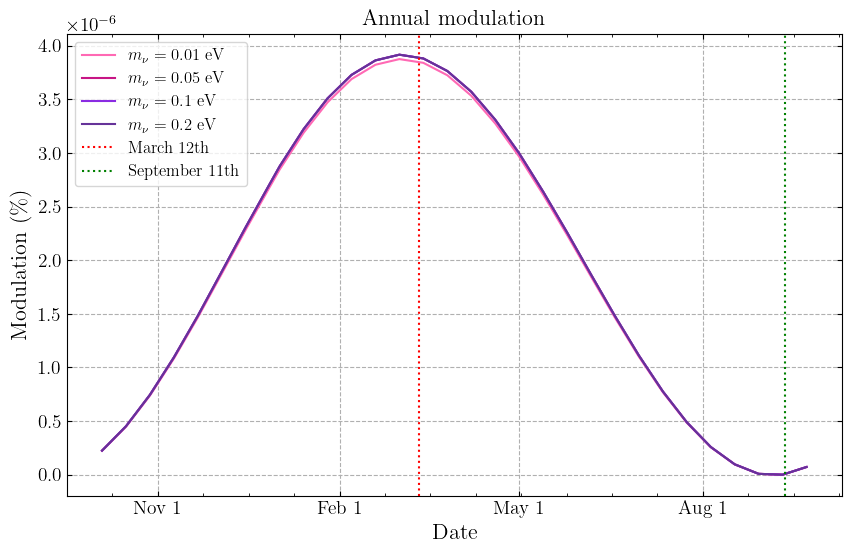

In [13]:
def modulation_band(
        nu_dens_days, simulated_days, nu_m_picks, 
        start_date_str='09-11', mode='modulation', pdf_suffix=""):
    
    fig = plt.figure(figsize=(10, 6))
    fig.tight_layout()
    ax = fig.add_subplot(111)

    # Convert start_date_str to datetime object
    start_date = datetime.strptime(start_date_str, '%m-%d')
    
    # Calculate the day of the year for the start date
    start_day_of_year = start_date.timetuple().tm_yday

    # Shift days to start from the specified date
    shifted_days = (simulated_days - start_day_of_year) % 365 + 1
    sorted_indices = jnp.argsort(shifted_days)
    shifted_days = shifted_days[sorted_indices]

    # Adjust vertical lines for March 12th and September 11th
    march_12 = (datetime_date(2000, 3, 12) - datetime_date(2000, start_date.month, start_date.day)).days % 365 + 1
    sept_11 = (datetime_date(2000, 9, 11) - datetime_date(2000, start_date.month, start_date.day)).days % 365 + 1

    violet_colors = [
        # "lightpink",
        "hotpink", 
        "mediumvioletred", 
        "blueviolet",
        "rebeccapurple",
    ]

    for m_idx, (m_val, color) in enumerate(zip(nu_m_picks, violet_colors)):

        # if m_val != nu_m_picks[3]:
        #     continue

        # Select current mass
        nu_dens_m = nu_dens_days[..., m_idx]

        #? Since we started from Dec 31st to Jan 1st, we should flip array?
        nu_dens_m = jnp.flip(nu_dens_m, axis=0)

        # Compute fractional modulation for each halo
        nu_min = jnp.min(nu_dens_m, axis=0)
        mod = (nu_dens_m - nu_min) / (nu_dens_m + nu_min) * 100

        if mode == 'densities':
            mod = nu_dens_m
            plt.title("Number densities")
            plt.ylabel(r'$n_\nu$ [${\rm cm}^-3$]')

            if m_idx == 0:
                plt.axhline(y=Params.N0_cm3, color='k', linestyle=":", label=r"$\Lambda$CDM $n_\nu$")
        else:
            plt.title("Annual modulation")
            plt.ylabel(r'Modulation ($\%$)')

        # Sort modulation values for each day
        # mod_sorted = jnp.sort(mod, axis=1)

        # Compute median and 1-sigma band
        median = jnp.median(mod, axis=-1)
        lower = jnp.percentile(mod, 16, axis=-1)
        upper = jnp.percentile(mod, 84, axis=-1)

        # Apply sorting to match shifted_days
        median = median[sorted_indices]
        lower = lower[sorted_indices]
        upper = upper[sorted_indices]

        # Plot median and 1-sigma band
        ax.plot(shifted_days, median, '-', color=color, label=fr"$m_\nu = {m_val}$ eV")
        # ax.fill_between(shifted_days, lower, upper, color=color, alpha=0.3)

    # Calculate tick positions and labels
    tick_dates = [datetime_date(2000, 11, 1), datetime_date(2000, 2, 1), 
                datetime_date(2000, 5, 1), datetime_date(2000, 8, 1)]
    tick_days = [(d - datetime_date(2000, start_date.month, start_date.day)).days % 365 + 1 for d in tick_dates]
    tick_labels = ['Nov 1', 'Feb 1', 'May 1', 'Aug 1']

    plt.xticks(tick_days, tick_labels)

    # Set axis limits and labels
    # plt.ylim(0, 5)
    # plt.ylim(0.999*Params.N0_cm3, 1.001*Params.N0_cm3)
    plt.xlabel('Date')
    plt.legend()
    plt.grid(True, which="major", linestyle="dashed")

    plt.axvline(x=march_12, color='r', linestyle=':', label='March 12th')
    plt.axvline(x=sept_11, color='g', linestyle=':', label='September 11th')

    plt.legend(prop={"size":12})

    pdf_name = f"modulation{pdf_suffix}"
    plt.savefig(f"{fig_folder}/{pdf_name}.pdf", bbox_inches="tight")

    plt.show()
    plt.close()


# suffix = "_test"
# suffix = ""
# suffix = "_circular"
# suffix = "_circular_Earth_frame"
# suffix = "_circular_Earth_frame_dipoleFD"
# suffix = "_circular_FD_boosted"

# suffix = "_Sun_MW_p_Earth_FD_boost"
# suffix = "_Sun_MW_FD_boost"
# suffix = "_Sun_CNB_p_Earth_FD_boost"
suffix = "_Sun_CNB_FD_boost"

nu_base_name = f"n_nu_days{suffix}"
n_nu_days = jnp.load(f"{sim_folder}/{nu_base_name}.npy")
print(f"n_nu_days shape: {n_nu_days.shape}")

nrs_base_name = f"days_nrs{suffix}"
days_nrs = jnp.load(f"{sim_folder}/{nrs_base_name}.npy")

# """
# Call the modulation function with the full n_nu_days array
modulation_band(
    nu_dens_days=n_nu_days, 
    simulated_days=days_nrs,
    nu_m_picks=nu_m_picks,
    start_date_str="09-23",
    # mode='densities',
    # pdf_suffix=f"{suffix}_densities",
    pdf_suffix=f"{suffix}_modulation",
)
# """